In [1]:
# ============================================================
# 03 - Model Training
# ============================================================
# Owner: Peter Wilson
# Purpose: Train and tune all four ML models (Random Forest,
#          XGBoost, SVM, Decision Tree) on the full feature
#          set. Save all trained models to results/ and log
#          all metrics to results/metrics.csv
# ============================================================


In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)
import joblib
from src.models import train_and_evaluate
from src.utils import load_splits, plot_confusion_matrix

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = load_splits()

print("Splits loaded:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")

Splits loaded:
  X_train: (164484, 50)
  X_val:   (35254, 50)
  X_test:  (35249, 50)


In [4]:
models = {
    'RandomForest': RandomForestClassifier(
                        n_estimators=100, random_state=489),
    'XGBoost':      XGBClassifier(
                        random_state=489, eval_metric='logloss'),
    'DecisionTree': DecisionTreeClassifier(random_state=489)
}

Training RandomForest...
Model saved to results/RandomForest.pkl


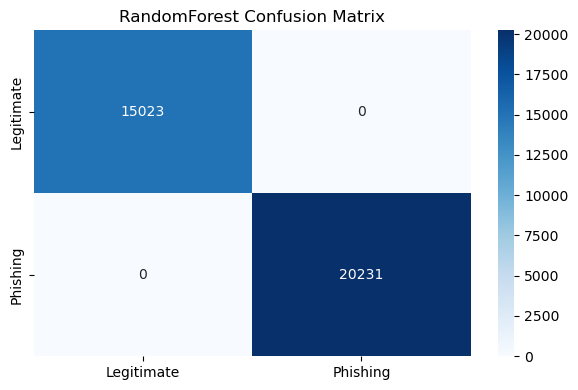

  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1:        1.0000
  AUC:       1.0000
  Inference: 0.0022ms

Training XGBoost...
Model saved to results/XGBoost.pkl


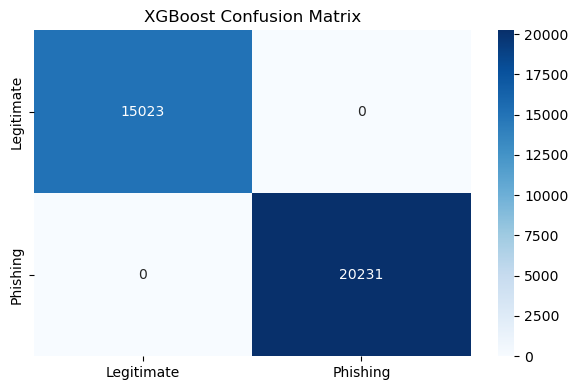

  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1:        1.0000
  AUC:       1.0000
  Inference: 0.0003ms

Training DecisionTree...
Model saved to results/DecisionTree.pkl


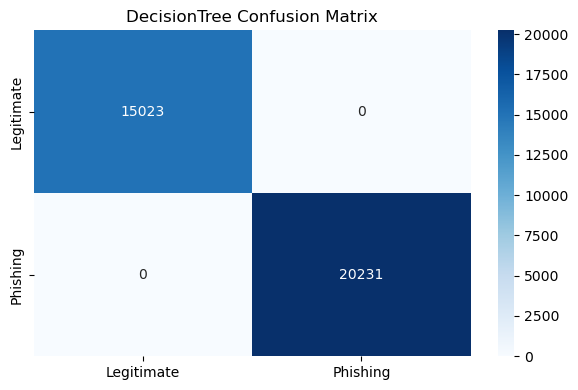

  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1:        1.0000
  AUC:       1.0000
  Inference: 0.0002ms



In [5]:
all_results = []

for name, model in models.items():
    print(f"Training {name}...")
    results, cm = train_and_evaluate(
        model, name, X_train, y_train, X_val, y_val
    )
    all_results.append(results)
    plot_confusion_matrix(cm, name)
    print(f"  Accuracy:  {results['accuracy']:.4f}")
    print(f"  Precision: {results['precision']:.4f}")
    print(f"  Recall:    {results['recall']:.4f}")
    print(f"  F1:        {results['f1']:.4f}")
    print(f"  AUC:       {results['auc']:.4f}")
    print(f"  Inference: {results['inference_ms']:.4f}ms\n")

In [6]:
results_df = pd.DataFrame(all_results)
results_df.to_csv('../results/metrics.csv', index=False)

print("All results saved to results/metrics.csv")
print(results_df[['model','accuracy','precision',
                   'recall','f1','auc','inference_ms']])

All results saved to results/metrics.csv
          model  accuracy  precision  recall   f1  auc  inference_ms
0  RandomForest       1.0        1.0     1.0  1.0  1.0        0.0022
1       XGBoost       1.0        1.0     1.0  1.0  1.0        0.0003
2  DecisionTree       1.0        1.0     1.0  1.0  1.0        0.0002


In [7]:
rf_model = joblib.load('../results/RandomForest.pkl')

feature_importance = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 most important features:")
print(feature_importance.head(10))

Top 10 most important features:
               feature  importance
3   URLSimilarityIndex    0.195610
49     NoOfExternalRef    0.178708
47         NoOfSelfRef    0.100250
22          LineOfCode    0.092157
46              NoOfJS    0.087750
44           NoOfImage    0.081950
36        HasSocialNet    0.049673
32      HasDescription    0.031941
45             NoOfCSS    0.031690
43    HasCopyrightInfo    0.029308


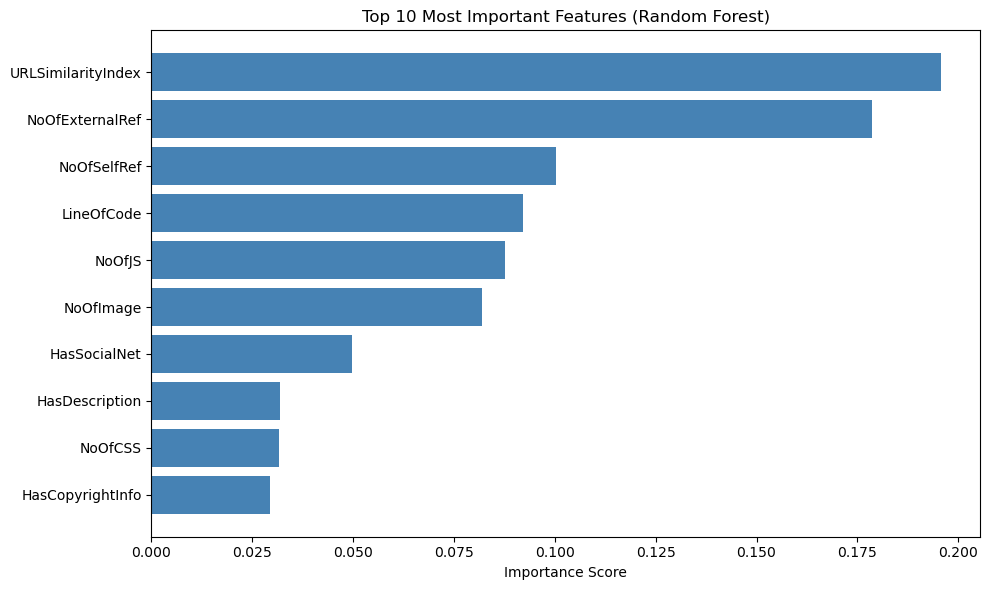

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['feature'], 
         top_features['importance'],
         color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../results/figures/feature_importance.png', dpi=150)
plt.show()
